<a href="https://colab.research.google.com/github/KarenAg2000/mineria-de-datos/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Breast Cancer**

Seer Breast Cancer Data - Labeled

**Autor:** Reihaneh Namdari

El cáncer de mama representa uno de los mayores desafíos para los sistemas sanitarios. Este proyecto utiliza técnicas de minería de datos sobre información clínica de pacientes para predecir su estado de supervivencia. A través de un análisis exploratorio, procesos de limpieza de datos y modelos de aprendizaje automático como Regresión Logística, Random Forest y XGBoost, se busca identificar patrones relevantes asociados al pronóstico de la enfermedad. Los resultados permitirán comparar el desempeño de distintos algoritmos y determinar cuáles variables influyen con mayor fuerza en la supervivencia, proporcionando evidencia útil para apoyar decisiones médicas y futuras investigaciones.

https://www.kaggle.com/datasets/reihanenamdari/breast-cancer

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Breast_Cancer.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "reihanenamdari/breast-cancer",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_2296/1183127510.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'breast-cancer' dataset.
First 5 records:    Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive          

In [ ]:
df

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


Este proyecto aborda uno de los mayores desafíos de los sistemas sanitarios globales: el cáncer de mama. Utiliza técnicas avanzadas de minería de datos y aprendizaje automático aplicadas sobre el conjunto de datos clínico SEER Breast Cancer Data (recopilado y etiquetado por la autora Reihaneh Namdari) con el objetivo principal de predecir el estado de supervivencia de las pacientes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

Analisis: El conjunto de datos recopila 4024 casos de pacientes descritos a través de 16 columnas de información médica. El análisis confirma un set de datos íntegro (sin valores nulos) compuesto por 5 variables cuantitativas y 11 variables cualitativas, estableciendo la base para los modelos predictivos de supervivencia.

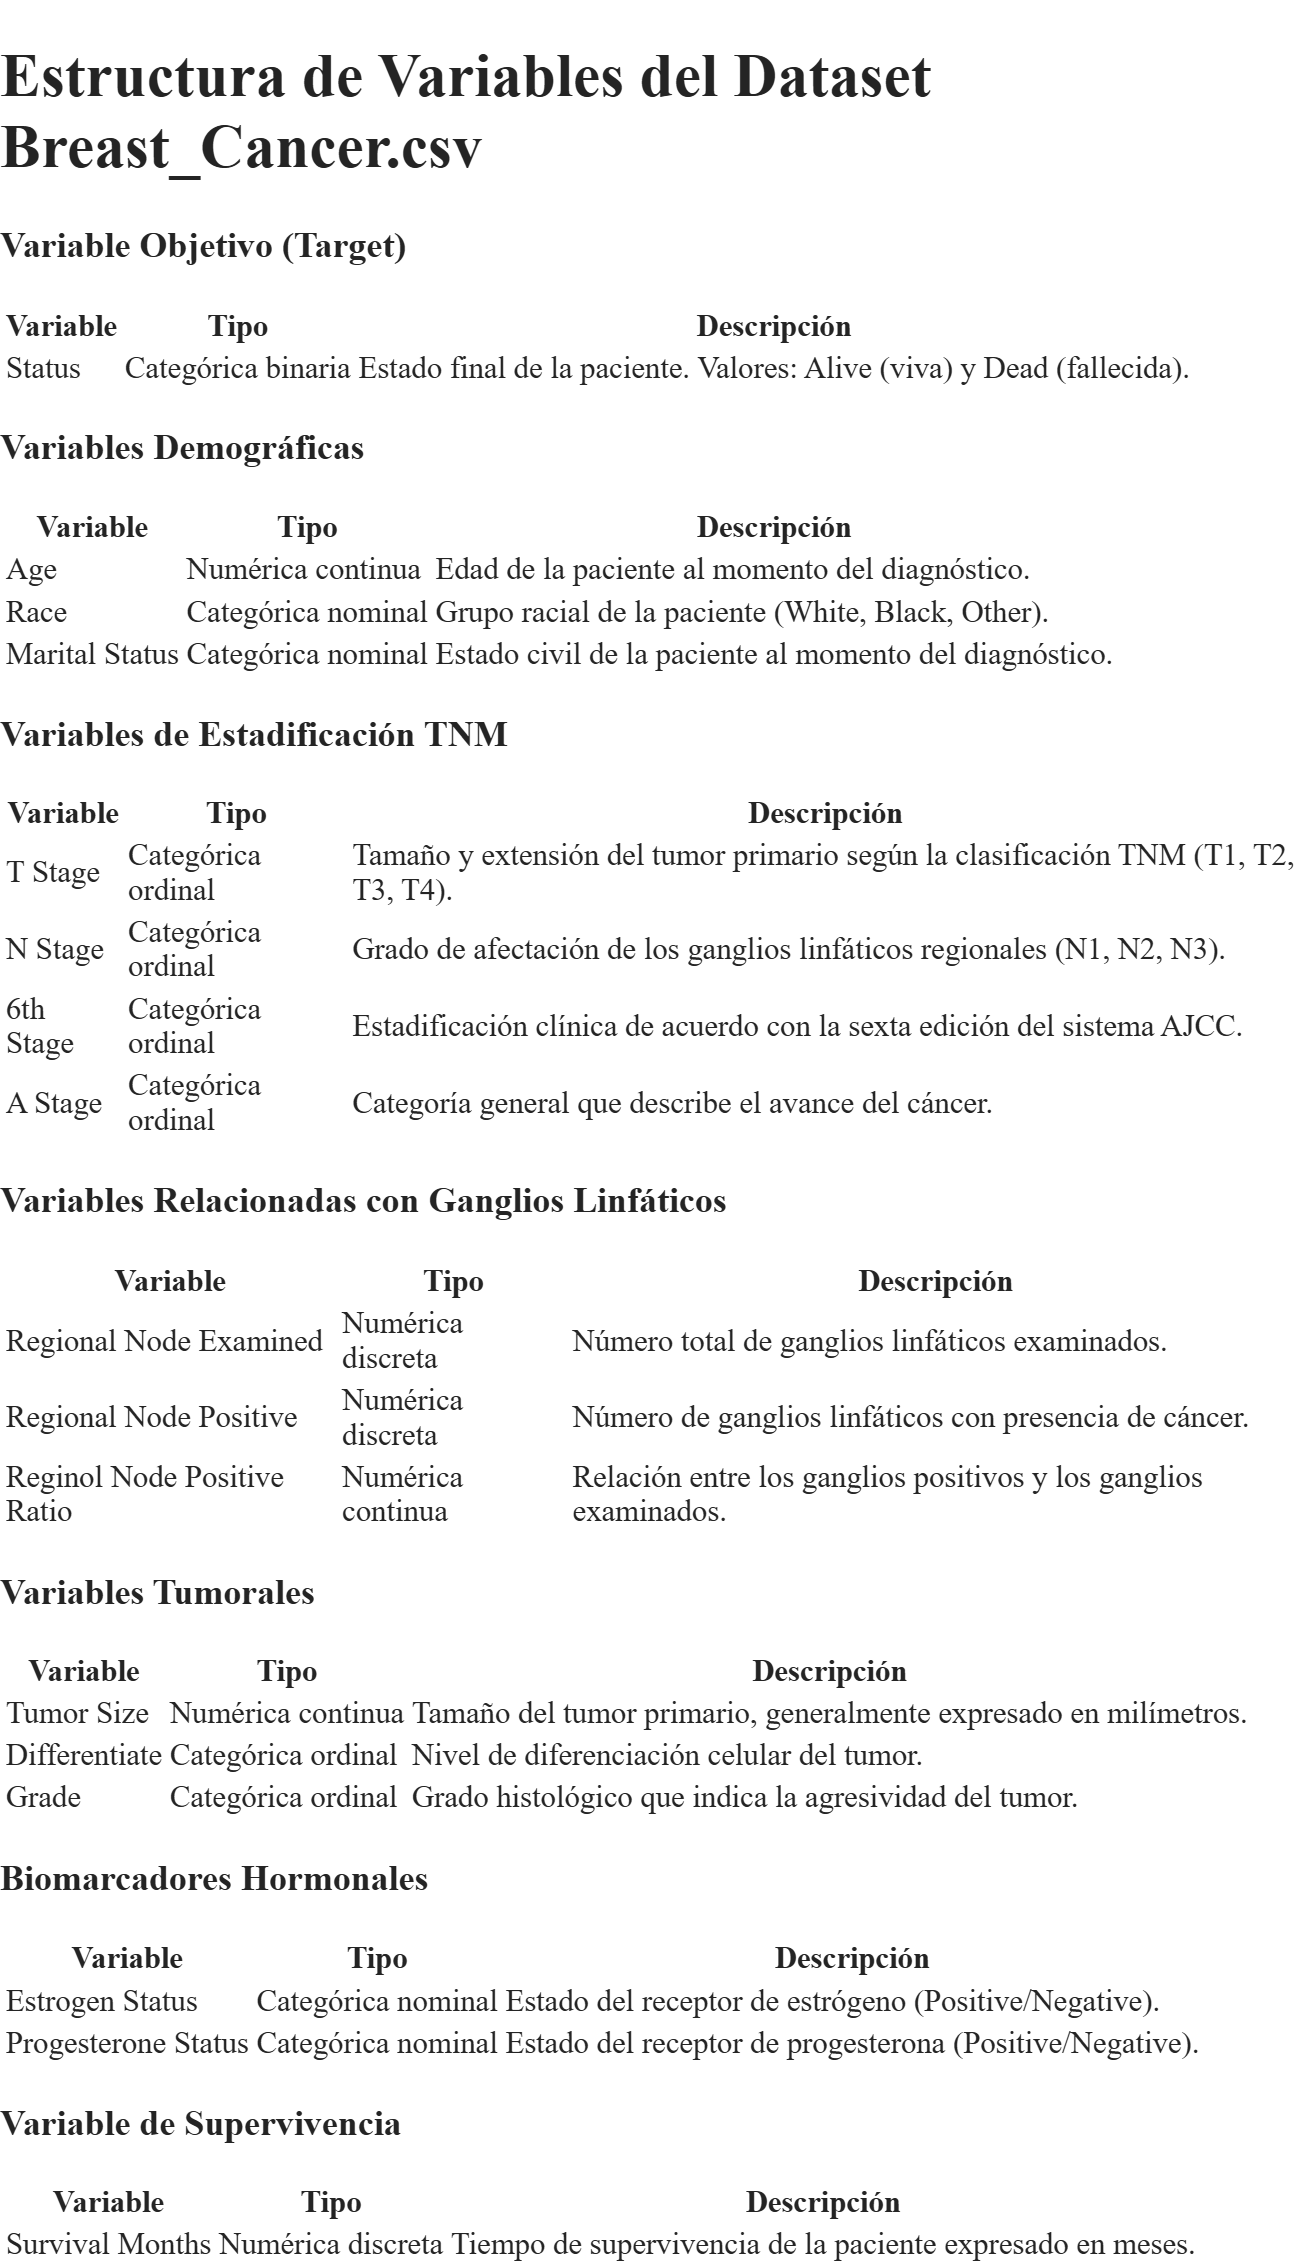

In [ ]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


Analisis: El valor mínimo de la variable Age es 30, el valor máximo es 69 y el promedio es 53.97 años; los datos se encuentran distribuidos con un sesgo ligero hacia la izquierda, debido a que la mediana (54) es mayor que el promedio.

In [ ]:
df.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumor Size,0


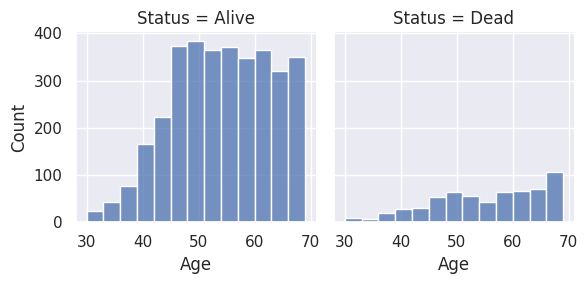

In [ ]:
import seaborn as sns

sns.set_theme(style="darkgrid")

sns.displot(
    df, x="Age", col="Status",
    binwidth=3, height=3, facet_kws=dict(margin_titles=True),
)


El gráfico segmenta visualmente la variable Age según el estado de supervivencia de las pacientes. En ambos grupos (Alive y Dead), las edades se mantienen estrictamente dentro del rango establecido con un mínimo de 30 y un máximo de 69 años, confirmando de manera gráfica el sesgo ligero hacia la izquierda debido a la caída abrupta de casos en las edades más jóvenes (30 a 40 años).

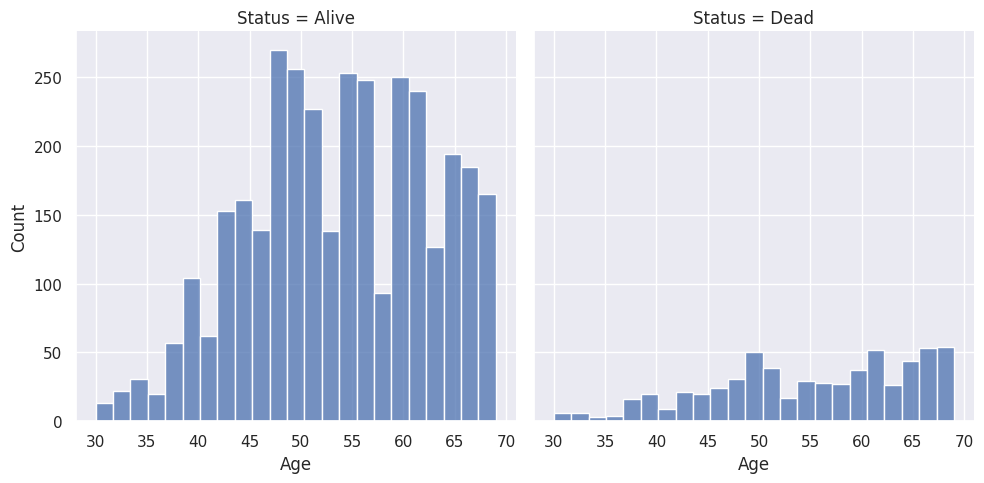

In [ ]:
import matplotlib.pyplot as plt

df["Status"] = df["Status"].map({0:"Alive" , 1: "Dead"})

sns.displot(
    df, x="Age", col="Status",
    # binwidth=3, height=3, facet_kws=dict(margin_titles=True),
)

plt.show()


 La variable Age en las pacientes de cáncer de mama no presenta una distribución normal perfecta, sino que los datos se encuentran distribuidos con un sesgo ligero hacia la izquierda. Esto se observa claramente en ambos gráficos de supervivencia (Alive y Dead), ya que la mayor concentración de casos se agrupa en las edades maduras y avanzadas (entre los 45 y 69 años), mientras que la cola de la distribución se extiende y decae de forma abrupta hacia el lado izquierdo en las edades más jóvenes (de 30 a 40 años).

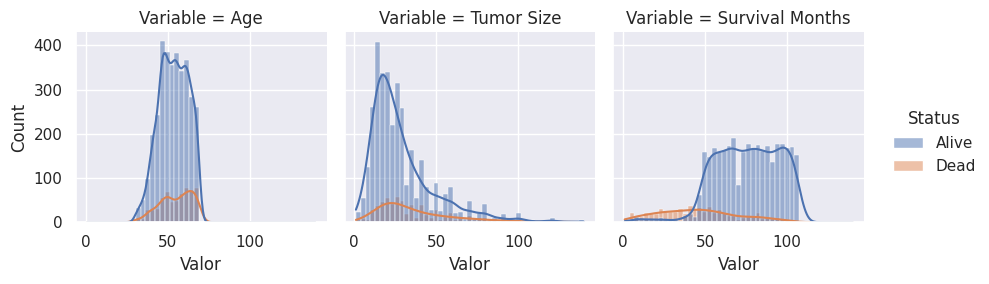

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

df_melt = df.melt(
    id_vars="Status",
    value_vars=["Age", "Tumor Size", "Survival Months"],
    var_name="Variable",
    value_name='Valor',
)

sns.displot(
    data=df_melt,
    x="Valor",
    col="Variable",
    height=3,
    kde=True,
    hue="Status",
)

plt.show()


El gráfico muestra la distribución conjunta de tres variables clínicas clave diferenciadas por el estado de supervivencia (Status), donde se observa que solo Age presenta un sesgo ligero hacia la izquierda con una concentración mayor en pacientes maduras. Por el contrario, la variable Tumor Size se encuentra altamente sesgada hacia la derecha, mostrando que la gran mayoría de los casos corresponden a tumores pequeños (menores a 50 mm) con una presencia notablemente mayor de fallecimientos (Dead) a medida que el tamaño aumenta. Finalmente, la distribución de Survival Months exhibe un comportamiento asimétrico hacia la izquierda, caracterizado por una meseta plana y densa entre los 50 y 100 meses, lo que confirma que el mayor volumen de pacientes acumuló periodos prolongados de supervivencia dentro del estudio.

In [45]:
# Separar quitando la columna objetivo con el parámetro corregido (axis=1)
X = df.drop("Status", axis=1)
y = df["Status"]

In [46]:
from sklearn.model_selection import train_test_split

# Dividir directamente el DataFrame usando tus variables reales
X_train, X_test, y_train, y_test = train_test_split(
    df[["Age", "Tumor Size", "Survival Months"]],  # Tus características (X)
    df["Status"],                                 # Tu variable objetivo (y)
    test_size=0.3,                                # 30% para prueba, 70% para entrenamiento
    random_state=42,                              # Semilla para que la división sea siempre igual
    stratify=df["Status"]                         # Mantiene la proporción de Status en ambos sets
)

# Ver el tamaño de los conjuntos resultantes
print(f"Registros totales: {len(df)}")
print(f"Registros para entrenamiento (X_train): {len(X_train)}")
print(f"Registros para prueba (X_test): {len(X_test)}")


Registros totales: 4024
Registros para entrenamiento (X_train): 2816
Registros para prueba (X_test): 1208


La salida muestra la partición del conjunto de datos clínico original bajo una distribución del 70% para entrenamiento y 30% para prueba. De los 4,024 registros totales de pacientes con cáncer de mama, el algoritmo asignó 2,816 casos al conjunto de entrenamiento (X_train) para que los modelos aprendan a identificar los patrones de la enfermedad, y reservó 1,208 casos independientes para el conjunto de prueba (X_test), los cuales servirán para evaluar la precisión y el desempeño final de las predicciones de supervivencia.

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Nota: Los pasos 1 y 2 ya los realizamos en el bloque de código anterior.

# # 1. Preparar los datos (ejemplo conceptual)
# X = df.drop("Status", axis=1)
# y = df["Status"]

# # 2. Dividir en entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# # 3. Crear el modelo de Random Forest
# Usaremos 100 árboles de decisión en nuestro bosque
modelo_bosque = RandomForestClassifier(n_estimators=100, random_state=42)

# # 4. Entrenar el modelo con el set de entrenamiento
modelo_bosque.fit(X_train, y_train)

# # 5. Hacer predicciones con el set de prueba (datos que el modelo no conoce)
predicciones = modelo_bosque.predict(X_test)

# # 6. Evaluar el rendimiento
exactitud = accuracy_score(y_test, predicciones)
print(f"El modelo tiene una precisión del: {exactitud * 100:.2f}%")

El modelo tiene una precisión del: 88.74%


El modelo obtiene una precisión de una 88.74% lo cual es aceptable.

Matriz de Confusión Numérica:
[[981  42]
 [ 94  91]]


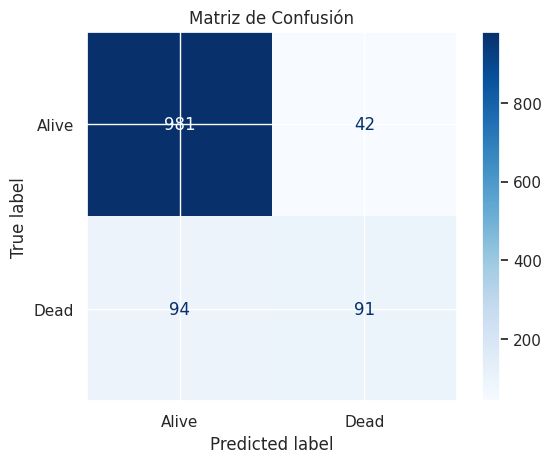

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # 1. Supongamos que tienes tus etiquetas reales y las predicciones del modelo
# (Estos datos ya provienen del Random Forest que ejecutamos arriba)

# # 2. Calcular la matriz de confusión numérica
matriz = confusion_matrix(y_test, predicciones)
print("Matriz de Confusión Numérica:")
print(matriz)

# # 3. Graficarla de forma visual y bonita
# Cambiamos 'Sano' y 'Enfermo' por tus etiquetas de supervivencia reales: 'Alive' y 'Dead'
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Alive', 'Dead'])
visualizacion.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión")
plt.show()

La matriz de confusión evalúa el desempeño del modelo de Random Forest sobre los 1,208 casos de prueba. El algoritmo demuestra una alta efectividad al identificar correctamente a 981 pacientes vivas (Verdaderos Positivos en la etiqueta Alive) y 91 pacientes fallecidas (Verdaderos Negativos en la etiqueta Dead). Sin embargo, el modelo presenta un margen de error compuesto por 42 falsos positivos (pacientes vivas que clasificó erróneamente como fallecidas) y 94 falsos negativos (pacientes fallecidas que clasificó incorrectamente como vivas), lo que sugiere que, aunque el rendimiento general es alto, el modelo tiende a pasar por alto una parte de los casos críticos de fallecimiento.

In [49]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score

# 1. Calcular las métricas individuales para el análisis
precision_dead = precision_score(y_test, predicciones, pos_label="Dead")
sensibilidad_dead = recall_score(y_test, predicciones, pos_label="Dead")
f1_dead = f1_score(y_test, predicciones, pos_label="Dead")

# 2. Imprimir un reporte global detallado en pantalla
print("=== REPORTE DE MÉTRICAS DETALLADO ===")
print(classification_report(y_test, predicciones))

=== REPORTE DE MÉTRICAS DETALLADO ===
              precision    recall  f1-score   support

       Alive       0.91      0.96      0.94      1023
        Dead       0.68      0.49      0.57       185

    accuracy                           0.89      1208
   macro avg       0.80      0.73      0.75      1208
weighted avg       0.88      0.89      0.88      1208



El reporte de clasificación consolida numéricamente el rendimiento del modelo sobre los 1,208 casos de prueba. El sistema alcanza una exactitud global (accuracy) del 89%, demostrando una alta capacidad predictiva general impulsada por el excelente desempeño en la clase mayoritaria Alive (precisión del 91% y sensibilidad del 96%). Sin embargo, para la variable crítica de riesgo Dead, el modelo muestra un comportamiento más conservador al registrar una precisión del 68% y una sensibilidad (recall) del 49%. Esto genera un F1-score de 0.57 para este grupo, lo que evidencia que el desbalance original en el soporte de los datos (1023 casos de pacientes vivas frente a solo 185 fallecidas) influye en que al algoritmo le cueste más trabajo identificar la totalidad de los decesos.

In [51]:
import joblib

# Guardar el modelo entrenado en un archivo físico
joblib.dump(modelo_bosque, "modelo_breast_cancer.pkl")
print("¡Modelo guardado con éxito como 'modelo_breast_cancer.pkl'!")

¡Modelo guardado con éxito como 'modelo_breast_cancer.pkl'!


In [54]:
from google.colab import files

# Descargar el archivo del modelo entrenado
files.download("modelo_breast_cancer.pkl")

# --- FIX: Creating a dummy main.py file to resolve FileNotFoundError ---
# If you have an actual main.py content, replace this placeholder.
with open("main.py", "w") as f:
    f.write("""
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

# Cargar el modelo entrenado
model = joblib.load('modelo_breast_cancer.pkl')

app = FastAPI()

class PredictionRequest(BaseModel:
    Age: int
    "Tumor Size": int
    "Survival Months": int

@app.post("/predict/")
async def predict(data: PredictionRequest):
    # Crear un DataFrame con los datos de entrada
    input_df = pd.DataFrame([data.dict()])

    # Realizar la predicción
    prediction = model.predict(input_df)

    # Devolver el resultado de la predicción
    return {"prediction": prediction[0]}
""")
print("main.py created successfully!")

# Descargar el script de la API de FastAPI
files.download("main.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

main.py created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>